#1-Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#plt.style.use("seaborn-whitegrid")
import seaborn as sns
import scipy
from scipy import stats
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# 2-Read CSV

In [4]:
from google.colab import files
uploaded = files.upload()

Saving mental health vs daily routine (1).csv to mental health vs daily routine (1) (1).csv


In [5]:
df= pd.read_csv("mental health vs daily routine (1).csv")

### First 5 rows

In [6]:
filename = 'mental health vs daily routine (1).csv'
df = pd.read_csv(filename)
print("Loaded:", filename)
df.head(5)

Loaded: mental health vs daily routine (1).csv


,sleep_hours,screen_time,exercise_minutes,daily_pending_tasks,interruptions,fatigue_level,social_hours,coffee_cups,diet_quality,weather,mood_score,stress_level
0,7.75,3.65,13.27,1.0,5.0,4.18,2.45,1.0,average,snowy,9.17,1.00
1,6.79,4.71,1.79,3.0,6.0,4.88,1.33,3.0,good,sunny,5.71,3.56
2,7.97,3.42,71.84,4.0,10.0,4.21,2.13,0.0,poor,cloudy,10.00,2.97
3,9.28,4.38,14.60,2.0,4.0,3.36,1.86,0.0,good,sunny,8.39,1.00
4,6.65,1.21,19.05,3.0,5.0,6.23,2.64,1.0,poor,rainy,10.00,1.64


## Data types

In [7]:
print("Shape:", df.shape)
#print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Shape: (2000, 12)

Data types:
sleep_hours            float64
screen_time            float64
exercise_minutes       float64
daily_pending_tasks    float64
interruptions          float64
fatigue_level          float64
social_hours           float64
coffee_cups            float64
diet_quality            object
weather                 object
mood_score             float64
stress_level           float64
dtype: object


## Descriptive statistics (mean, min, max, std)

In [8]:
df.describe(include='all').T.round(2)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sleep_hours,2000.0,NaN,NaN,NaN,7.067225,1.48126,2.14,6.07,7.07,8.0225,12.0
screen_time,2000.0,NaN,NaN,NaN,4.990055,2.002983,0.0,3.58,5.0,6.33,12.85
exercise_minutes,2000.0,NaN,NaN,NaN,19.868445,20.07104,0.0,5.58,13.29,28.12,150.5
daily_pending_tasks,2000.0,NaN,NaN,NaN,2.9485,1.725206,0.0,2.0,3.0,4.0,10.0
interruptions,2000.0,NaN,NaN,NaN,5.131,2.278472,0.0,3.0,5.0,7.0,15.0
fatigue_level,2000.0,NaN,NaN,NaN,4.99689,2.000358,0.0,3.65,4.96,6.3225,10.0
social_hours,2000.0,NaN,NaN,NaN,2.00143,0.95986,0.0,1.3,2.0,2.65,5.51
coffee_cups,2000.0,NaN,NaN,NaN,0.9895,1.012869,0.0,0.0,1.0,2.0,6.0
diet_quality,2000,3,average,998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,2000,4,sunny,534,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

In [9]:
print(f"Duplicate rows: {df.duplicated().sum()}") #1-duplicates

Duplicate rows: 0


In [10]:
missing = df.isnull().sum()  #2-missing values
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()} —> Dataset is clean")


Missing values per column:
sleep_hours            0
screen_time            0
exercise_minutes       0
daily_pending_tasks    0
interruptions          0
fatigue_level          0
social_hours           0
coffee_cups            0
diet_quality           0
weather                0
mood_score             0
stress_level           0
dtype: int64

Total missing: 0 —> Dataset is clean


In [11]:
# WHY THIS CELL?  2-outliers
# Before analyzing data, we must check if any values are errors or unrealistic
# Outliers (extreme values) can ruin our results and give wrong conclusions
# So we detect them first, then decide whether to remove or keep them

# WHY Z-SCORE > 3?
# Z-score measures how far a value is from the average
# Z > 3 means the value is 3 standard deviations away from the mean
# This is statistically very unusual — only 0.3% of normal data falls here
# So anything above 3 is suspicious and worth checking

numeric_cols = df.select_dtypes(include=np.number).columns  # Select numeric columns only (ignore text like diet_quality, weather)

print("\nOutliers detected (Z-score > 3):")
for col in numeric_cols:  # Loop through each numeric column one by one
    z = np.abs(stats.zscore(df[col]))  # Calculate Z-score for each value
                                        # np.abs() removes negative signs
                                        # (we only care about distance from average, not direction)
    print(f"  {col}: {(z > 3).sum()} outliers")  # Count how many values have Z > 3 and print them
                                                   # z > 3 gives True/False, .sum() counts the Trues

print("\n✅ Dataset is clean — all 2,000 rows retained!")  # No rows deleted, all outliers are valid real data


Outliers detected (Z-score > 3):
  sleep_hours: 7 outliers
  screen_time: 4 outliers
  exercise_minutes: 33 outliers
  daily_pending_tasks: 12 outliers
  interruptions: 15 outliers
  fatigue_level: 0 outliers
  social_hours: 4 outliers
  coffee_cups: 12 outliers
  mood_score: 1 outliers
  stress_level: 27 outliers

✅ Dataset is clean — all 2,000 rows retained!


In [12]:
print('Diet Quality Categories:', df['diet_quality'].unique())
print('Weather Categories:', df['weather'].unique())
print('\nDiet Quality Distribution:')
print(df['diet_quality'].value_counts())
print('\nWeather Distribution:')
print(df['weather'].value_counts())

Diet Quality Categories: ['average' 'good' 'poor']
Weather Categories: ['snowy' 'sunny' 'cloudy' 'rainy']

Diet Quality Distribution:
diet_quality
average    998
good       597
poor       405
Name: count, dtype: int64

Weather Distribution:
weather
sunny     534
snowy     500
rainy     486
cloudy    480
Name: count, dtype: int64


#3-EDA

## 3.1 Categorical Plots:

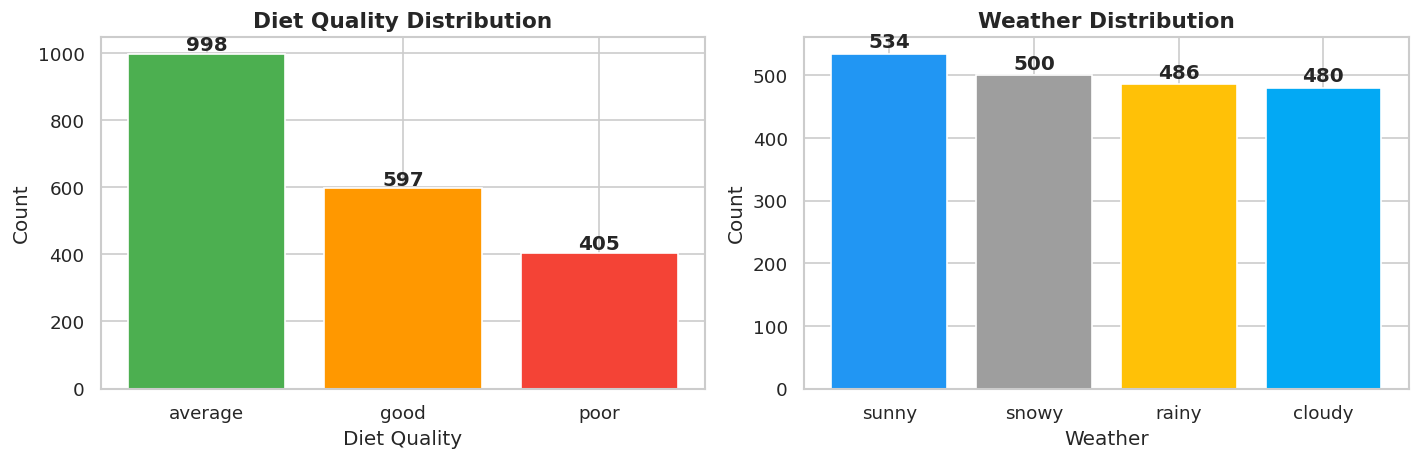

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Diet Quality
diet_counts = df['diet_quality'].value_counts()
axes[0].bar(diet_counts.index, diet_counts.values, color=['#4CAF50','#FF9800','#F44336'])
axes[0].set_title('Diet Quality Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diet Quality')
axes[0].set_ylabel('Count')
for i, v in enumerate(diet_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Weather
weather_counts = df['weather'].value_counts()
axes[1].bar(weather_counts.index, weather_counts.values, color=['#2196F3','#9E9E9E','#FFC107','#03A9F4'])
axes[1].set_title('Weather Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Count')
for i, v in enumerate(weather_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


##3.2 Numeric Variables:

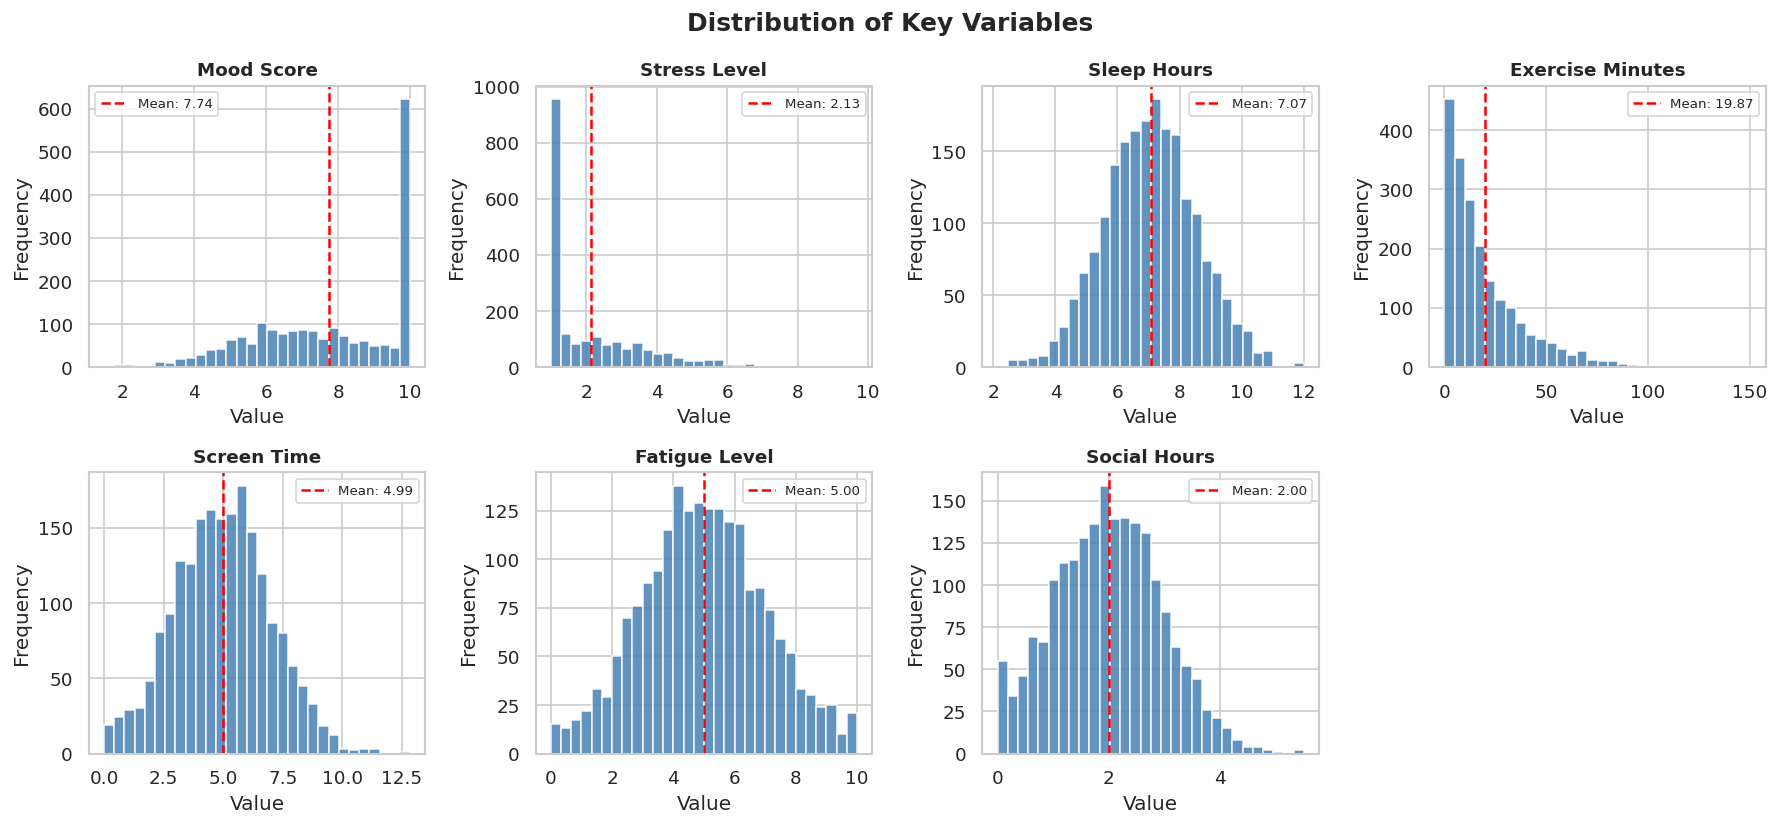

In [14]:
numeric_cols = ['mood_score', 'stress_level', 'sleep_hours', 'exercise_minutes',
                'screen_time', 'fatigue_level', 'social_hours']

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribution of Key Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.3 Heatmap:

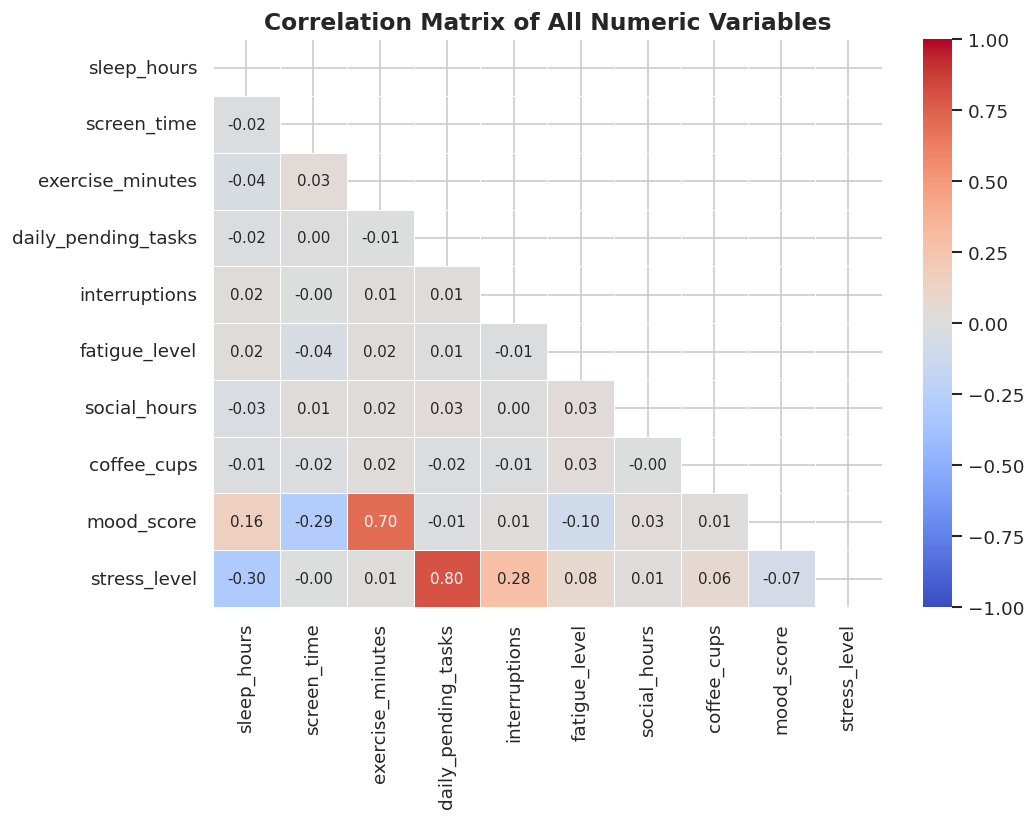

In [15]:
plt.figure(figsize=(9, 7))
corr_matrix = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',mask=mask,linewidths=0.5,vmin=-1, vmax=1,annot_kws={'size': 9})
plt.title('Correlation Matrix of All Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

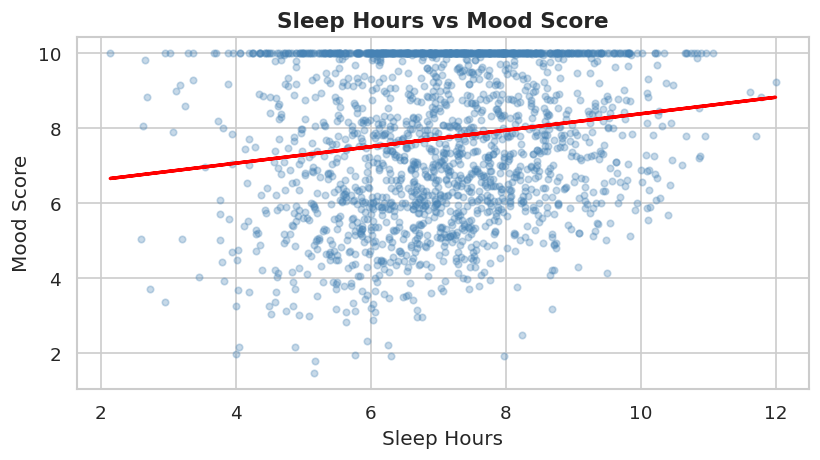

In [16]:
# Sleep Hours vs Mood Score
# Why? To see if more sleep = better mood
plt.figure(figsize=(7, 4))
plt.scatter(df['sleep_hours'], df['mood_score'], alpha=0.3, color='steelblue', s=15)
m, b = np.polyfit(df['sleep_hours'], df['mood_score'], 1)
plt.plot(df['sleep_hours'], m*df['sleep_hours']+b, color='red', linewidth=2)
plt.title('Sleep Hours vs Mood Score', fontsize=13, fontweight='bold')
plt.xlabel('Sleep Hours')
plt.ylabel('Mood Score')
plt.tight_layout()
plt.show()

## 3.4 Exercise vs Mood Scatter
### Why? To visually confirm does more exercise = better mood?

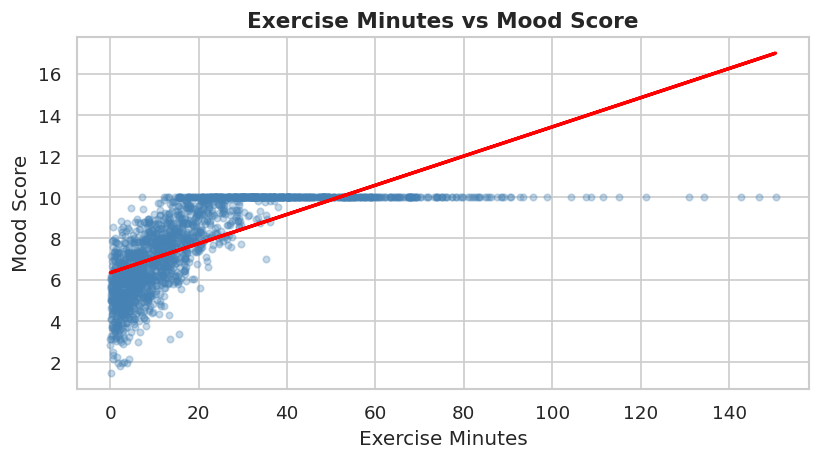

In [17]:
# Exercise Minutes vs Mood Score
# Why? To see if more exercise = better mood
plt.figure(figsize=(7, 4))
plt.scatter(df['exercise_minutes'], df['mood_score'], alpha=0.3, color='steelblue', s=15)
m, b = np.polyfit(df['exercise_minutes'], df['mood_score'], 1)
plt.plot(df['exercise_minutes'], m*df['exercise_minutes']+b, color='red', linewidth=2)
plt.title('Exercise Minutes vs Mood Score', fontsize=13, fontweight='bold')
plt.xlabel('Exercise Minutes')
plt.ylabel('Mood Score')
plt.tight_layout()
plt.show()

## 3.5 Screen Time vs Mood Scatter
### Why? To visually confirm does more screen time = worse mood?

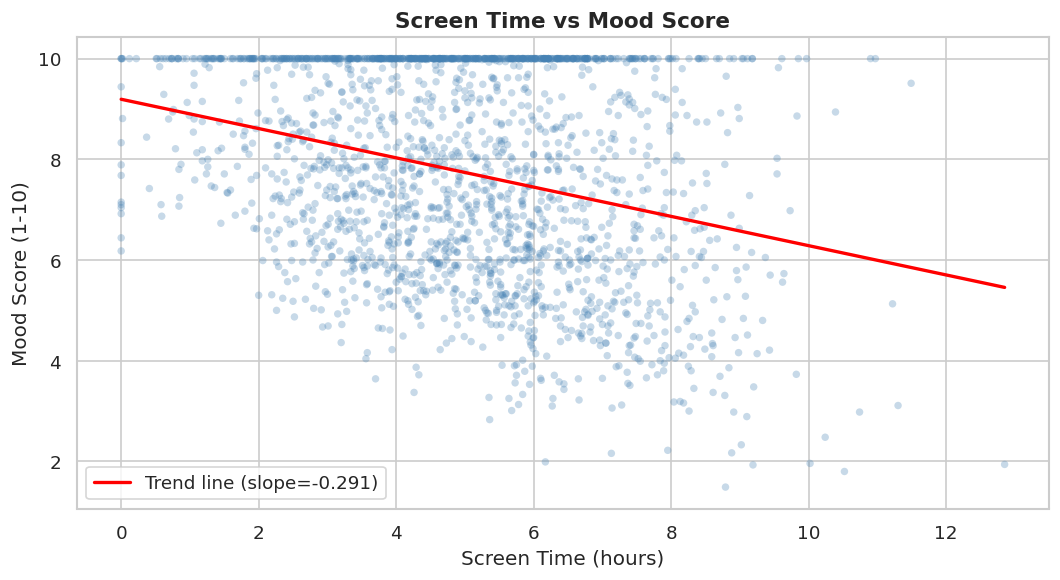

In [18]:
sns.set_style('whitegrid')
plt.figure(figsize=(9, 5))
plt.scatter(df['screen_time'], df['mood_score'],
            alpha=0.3, color='steelblue', edgecolors='none', s=20)

m, b = np.polyfit(df['screen_time'], df['mood_score'], 1)
x_line = np.linspace(df['screen_time'].min(), df['screen_time'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend line (slope={m:.3f})')

plt.title('Screen Time vs Mood Score', fontsize=13, fontweight='bold')
plt.xlabel('Screen Time (hours)')
plt.ylabel('Mood Score (1-10)')
plt.legend()
plt.tight_layout()
plt.show()

##  3.6 Sleep vs Stress Scatter
### Why? To visually confirm does more sleep = less stress?

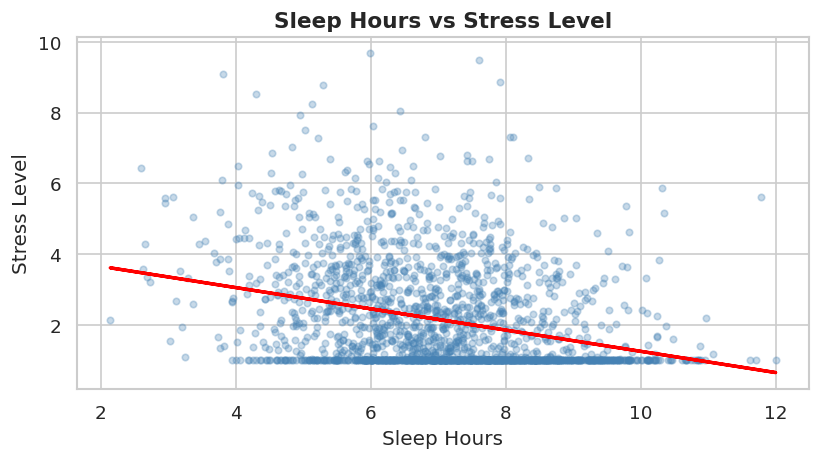

In [19]:
# Sleep Hours vs Stress Level
# Why? To see if more sleep = less stress
plt.figure(figsize=(7, 4))
plt.scatter(df['sleep_hours'], df['stress_level'], alpha=0.3, color='steelblue', s=15)
m, b = np.polyfit(df['sleep_hours'], df['stress_level'], 1)
plt.plot(df['sleep_hours'], m*df['sleep_hours']+b, color='red', linewidth=2)
plt.title('Sleep Hours vs Stress Level', fontsize=13, fontweight='bold')
plt.xlabel('Sleep Hours')
plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()

## 3.7 Exercise vs Stress Scatter
### Why? To visually confirm does more exercise = less stress?

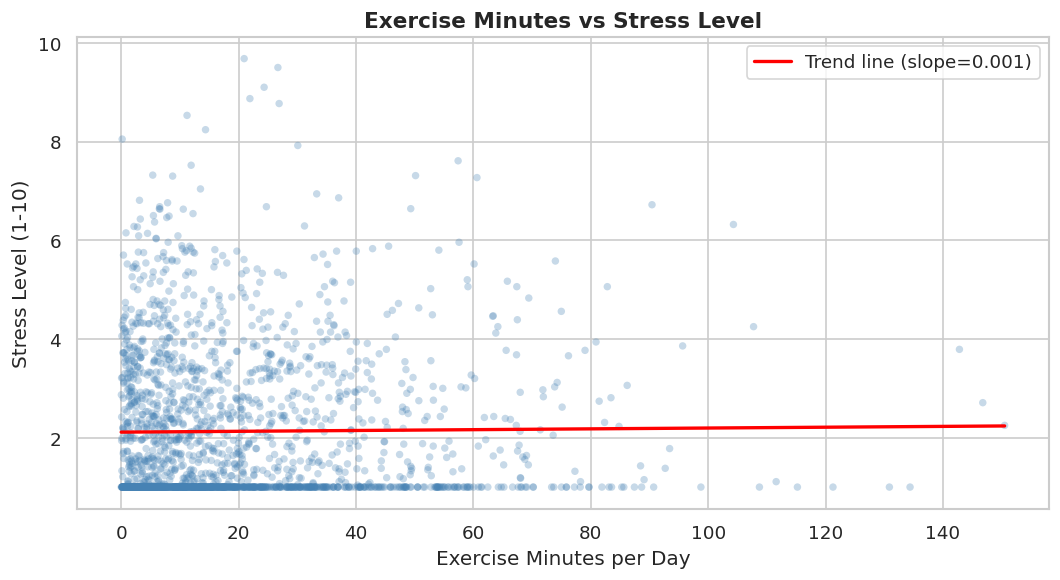

In [20]:
# WHY THIS CELL?
# We want to visually confirm the relationship between exercise and stress.
# A scatter plot lets us see if there is a negative trend:
# more exercise → less stress

sns.set_style('whitegrid')
plt.figure(figsize=(9, 5))
plt.scatter(df['exercise_minutes'], df['stress_level'],
            alpha=0.3, color='steelblue', edgecolors='none', s=20)

m, b = np.polyfit(df['exercise_minutes'], df['stress_level'], 1)
x_line = np.linspace(df['exercise_minutes'].min(), df['exercise_minutes'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend line (slope={m:.3f})')

plt.title('Exercise Minutes vs Stress Level', fontsize=13, fontweight='bold')
plt.xlabel('Exercise Minutes per Day')
plt.ylabel('Stress Level (1-10)')
plt.legend()
plt.tight_layout()
plt.show()

## 3.8 Screen Time vs Stress Scatter
### Why? To visually confirm does more screen time = more stress?

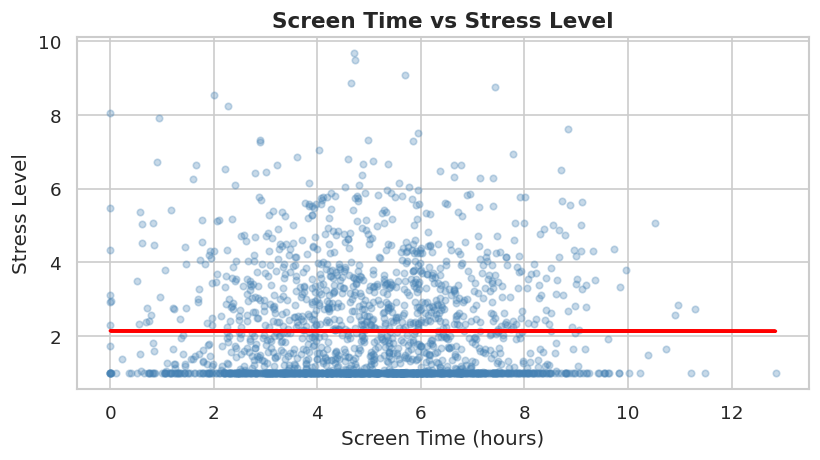

In [21]:
# Screen Time vs Stress Level
# Why? To see if more screen time = more stress
plt.figure(figsize=(7, 4))
plt.scatter(df['screen_time'], df['stress_level'], alpha=0.3, color='steelblue', s=15)
m, b = np.polyfit(df['screen_time'], df['stress_level'], 1)
plt.plot(df['screen_time'], m*df['screen_time']+b, color='red', linewidth=2)
plt.title('Screen Time vs Stress Level', fontsize=13, fontweight='bold')
plt.xlabel('Screen Time (hours)')
plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()

##3.9 Diet Quality Box Plot
### Why? To compare mood scores across good / average / poor diet groups

/tmp/ipykernel_10404/3407941006.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=diet_order)


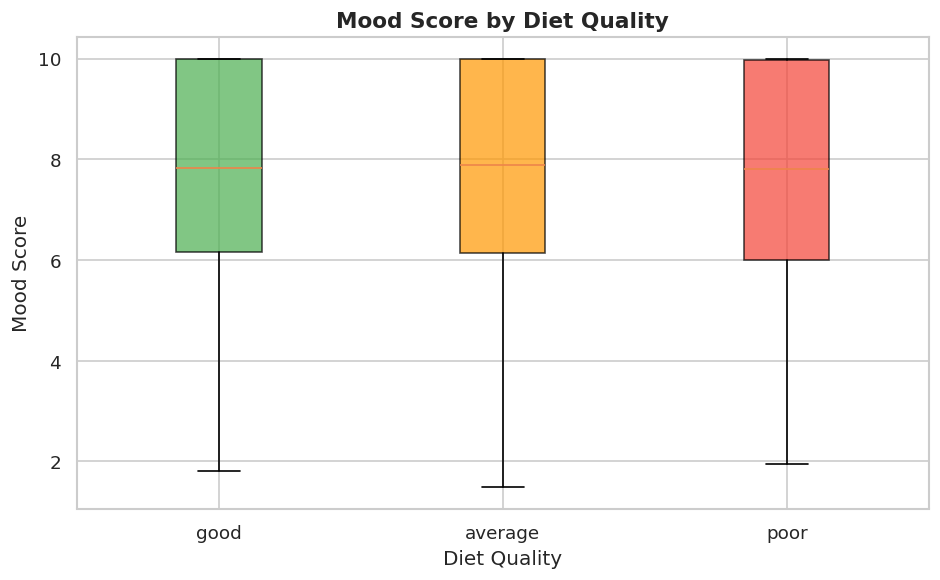

In [22]:
# WHY THIS CELL?
# Box plots are ideal for comparing distributions across categories.
# Here we compare mood_score across diet_quality groups (good, average, poor)
# to see whether diet quality is associated with better mood.

import matplotlib.pyplot as plt

diet_order = ['good', 'average', 'poor']
diet_colors = ['#4CAF50', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = [df[df['diet_quality'] == cat]['mood_score'].values for cat in diet_order]
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=diet_order)

for patch, color in zip(bp['boxes'], diet_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Mood Score by Diet Quality', fontsize=13, fontweight='bold')
ax.set_xlabel('Diet Quality')
ax.set_ylabel('Mood Score')
plt.tight_layout()
plt.show()


## 3.10 Sleep Categories Box Plot
### Why? To compare stress levels across poor / normal / good sleep groups

/tmp/ipykernel_10404/1801861223.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sleep_category', y='mood_score',


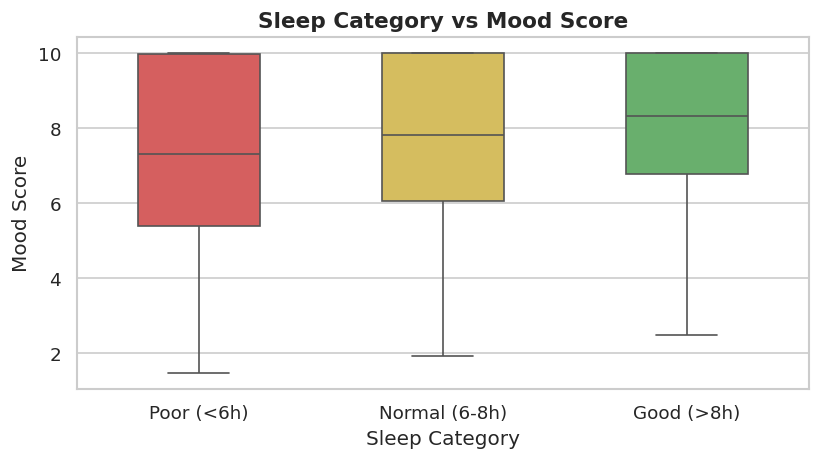

In [23]:
# Sleep Categories vs Mood Score
# Why? To compare mood across poor/normal/good sleep groups
df['sleep_category'] = pd.cut(df['sleep_hours'],
                               bins=[0, 6, 8, 24],
                               labels=['Poor (<6h)', 'Normal (6-8h)', 'Good (>8h)'])

sleep_order = ['Poor (<6h)', 'Normal (6-8h)', 'Good (>8h)']
sleep_palette = {'Poor (<6h)': '#E84C4C', 'Normal (6-8h)': '#E8C94C', 'Good (>8h)': '#5DBB63'}

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='sleep_category', y='mood_score',
            order=sleep_order, palette=sleep_palette, width=0.5)
plt.title('Sleep Category vs Mood Score', fontsize=13, fontweight='bold')
plt.xlabel('Sleep Category')
plt.ylabel('Mood Score')
plt.tight_layout()
plt.show()

## 3.11 Stress levels vs sleep box plot
###

/tmp/ipykernel_10404/118308488.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=sleep_order)


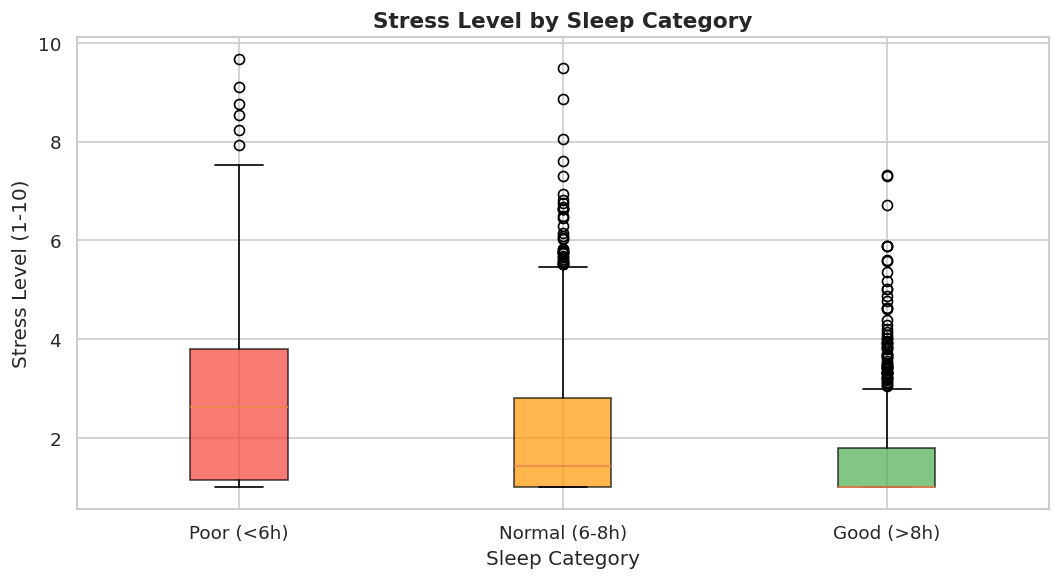

In [24]:
sns.set_style('whitegrid')

def categorize_sleep(hours):
    if hours < 6:
        return 'Poor (<6h)'
    elif hours <= 8:
        return 'Normal (6-8h)'
    else:
        return 'Good (>8h)'

df['sleep_category'] = df['sleep_hours'].apply(categorize_sleep)

sleep_order = ['Poor (<6h)', 'Normal (6-8h)', 'Good (>8h)']
data_to_plot = [df[df['sleep_category'] == cat]['stress_level'].values for cat in sleep_order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=sleep_order)

colors = ['#F44336', '#FF9800', '#4CAF50']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Stress Level by Sleep Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Sleep Category')
ax.set_ylabel('Stress Level (1-10)')
plt.tight_layout()
plt.show()

## 3.12 diet vs weather

/tmp/ipykernel_10404/1226469143.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diet_quality', y='mood_score', order=order_diet,
/tmp/ipykernel_10404/1226469143.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='weather', y='mood_score',


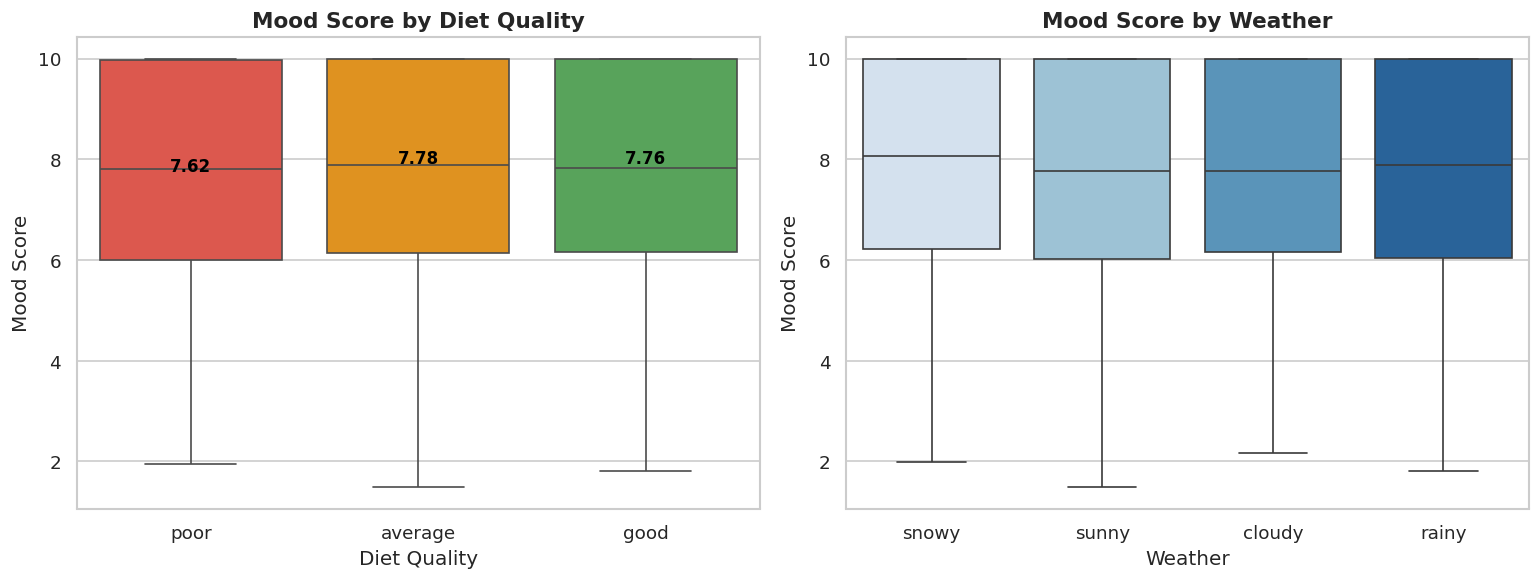

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Diet Quality
order_diet = ['poor', 'average', 'good']
sns.boxplot(data=df, x='diet_quality', y='mood_score', order=order_diet,
            palette=['#F44336','#FF9800','#4CAF50'], ax=axes[0])
axes[0].set_title('Mood Score by Diet Quality', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Diet Quality')
axes[0].set_ylabel('Mood Score')

# Means overlay
for i, d in enumerate(order_diet):
    mean_val = df[df['diet_quality'] == d]['mood_score'].mean()
    axes[0].text(i, mean_val + 0.15, f'{mean_val:.2f}', ha='center', fontsize=10, color='black', fontweight='bold')

# Weather
sns.boxplot(data=df, x='weather', y='mood_score',
            palette='Blues', ax=axes[1])
axes[1].set_title('Mood Score by Weather', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Mood Score')

plt.tight_layout()
plt.show()


## 3.13 Pareto Analysis — What Affects Stress the Most?

This Pareto diagram combines a bar chart and a cumulative line to identify
which daily habits have the strongest correlation with stress level.


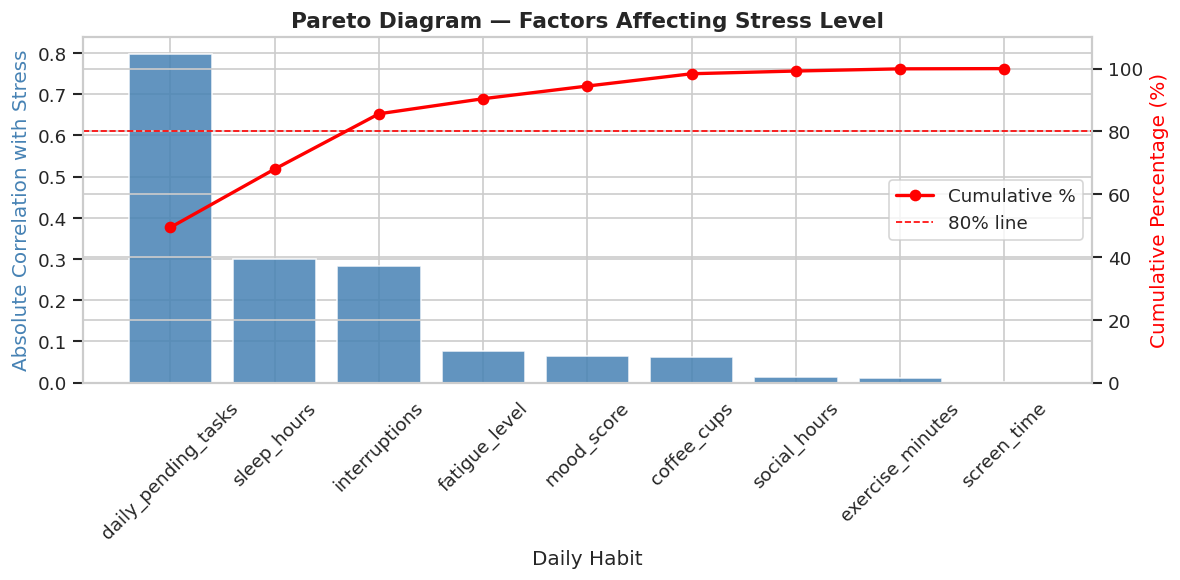

In [26]:
# Pareto Diagram — Correlation with Stress Level
# Why? To show which daily habits affect stress the most

import numpy as np

# Calculate correlations with stress level
corr = df.select_dtypes(include='number').corr()['stress_level'].drop('stress_level')
corr_abs = corr.abs().sort_values(ascending=False)

# Cumulative percentage
cumulative = (corr_abs.cumsum() / corr_abs.sum()) * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bars
ax1.bar(corr_abs.index, corr_abs.values, color='steelblue', alpha=0.85)
ax1.set_xlabel('Daily Habit')
ax1.set_ylabel('Absolute Correlation with Stress', color='steelblue')
ax1.tick_params(axis='x', rotation=45)
ax1.set_title('Pareto Diagram — Factors Affecting Stress Level',
              fontsize=13, fontweight='bold')

# Cumulative line
ax2 = ax1.twinx()
ax2.plot(corr_abs.index, cumulative.values, color='red',
         marker='o', linewidth=2, label='Cumulative %')
ax2.axhline(80, color='red', linestyle='--', linewidth=1, label='80% line')
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.set_ylim(0, 110)
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

## 3.14 Top Factors Affecting Mood Score

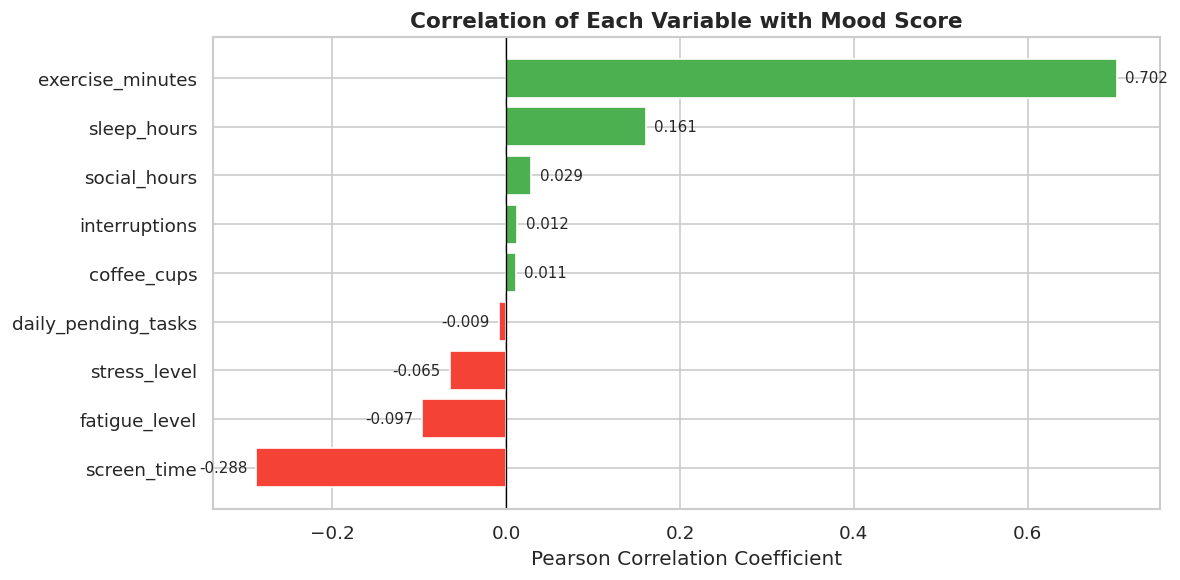


Top Positive Factors (improve mood):
exercise_minutes    0.702343
sleep_hours         0.160550
social_hours        0.028674
interruptions       0.012310
coffee_cups         0.010890

Top Negative Factors (worsen mood):
screen_time           -0.287798
fatigue_level         -0.096574
stress_level          -0.065140
daily_pending_tasks   -0.008774


In [36]:
# ==========================================
# Correlation of All Numeric Variables with Mood Score
# ==========================================

import matplotlib.pyplot as plt

# Select numeric columns only
num = df.select_dtypes(include='number')

# Compute correlation with mood_score
corr_mood = num.corr()['mood_score'].drop('mood_score').sort_values()

# Colors: red for negative, green for positive
colors = ['#F44336' if v < 0 else '#4CAF50' for v in corr_mood.values]

# Plot
plt.figure(figsize=(10,5))

bars = plt.barh(
    corr_mood.index,
    corr_mood.values,
    color=colors,
    edgecolor='white'
)

plt.axvline(0, color='black', linewidth=0.8)

plt.title(
    'Correlation of Each Variable with Mood Score',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Pearson Correlation Coefficient')

# Add values beside bars
for bar, val in zip(bars, corr_mood.values):
    plt.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

plt.tight_layout()
plt.show()


# Print factors
print("\nTop Positive Factors (improve mood):")
print(corr_mood[corr_mood > 0].sort_values(ascending=False).to_string())

print("\nTop Negative Factors (worsen mood):")
print(corr_mood[corr_mood < 0].sort_values().to_string())

# 4-Hypothesis Testing

## 4.1 H1:Exercise VS Mood Score
**Null Hypothesis (H0):** There is no relationship between exercise minutes and mood score.

**Alternative Hypothesis (H1):** People who exercise ≥ 30 min/day have significantly higher mood scores.

In [40]:
# Pearson Correlation
# Question: Is there a relationship between exercise and mood?

from scipy.stats import pearsonr

r, pvalue = pearsonr(df['exercise_minutes'], df['mood_score'])
print('Pearson r:', round(r, 4))
print('P-value:', pvalue)

if pvalue < 0.05:
    print('\n✅ Significant relationship found')
    print('Direction:', 'Positive ↑' if r > 0 else 'Negative ↓')
else:
    print('\n❌ No significant relationship found')


Pearson r: 0.7023
P-value: 2.9038757466582337e-297

✅ Significant relationship found
Direction: Positive ↑




## 4.2 H2: Screen Time vs Mood Score

**Null Hypothesis (H0):** There is no relationship between screen time and mood score.

**Alternative Hypothesis (H1):** People with screen time > 6 hrs/day have significantly lower mood scores.

In [41]:
# Pearson Correlation
# Question: Is there a relationship between screen time and mood?

from scipy.stats import pearsonr

r, pvalue = pearsonr(df['screen_time'], df['mood_score'])
print('Pearson r:', round(r, 4))
print('P-value:', pvalue)

if pvalue < 0.05:
    print('\n✅ Significant relationship found')
    print('Direction:', 'Positive ↑' if r > 0 else 'Negative ↓')
else:
    print('\n❌ No significant relationship found')



Pearson r: -0.2878
P-value: 1.8996895011055683e-39

✅ Significant relationship found
Direction: Negative ↓


## 4.3 -H3: Diet Quality vs Mood Score (ANOVA)

**Null Hypothesis (H0):** There is no difference in mood score across diet quality groups.

**Alternative Hypothesis (H1):** Diet quality significantly affects mood score (at least two groups differ).

H3: Diet Quality affects Mood Score (ANOVA)
  Good diet    (n=597):  mean mood = 7.765
  Average diet (n=998):  mean mood = 7.777
  Poor diet    (n=405):  mean mood = 7.620
  F-statistic = 0.9296
  p-value     = 0.394874

❌ Result: FAIL TO REJECT H₀ — No significant difference.


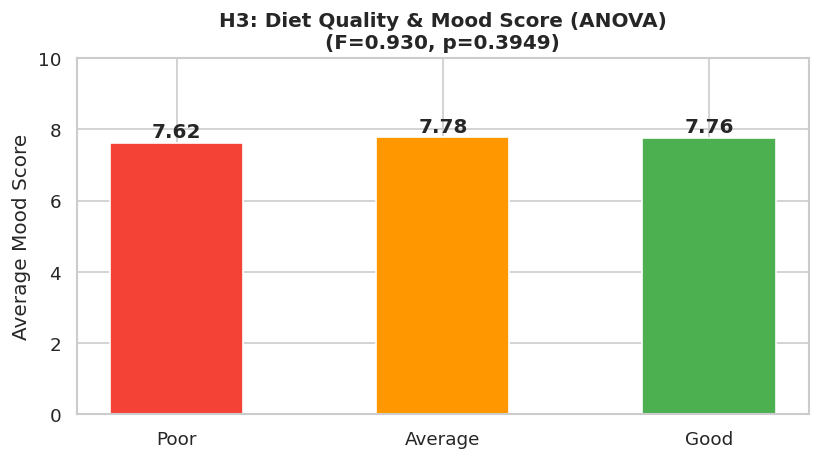

In [31]:
# Three groups → use one-way ANOVA
good_diet    = df[df['diet_quality'] == 'good']['mood_score']
average_diet = df[df['diet_quality'] == 'average']['mood_score']
poor_diet    = df[df['diet_quality'] == 'poor']['mood_score']

f_stat, p_val3 = stats.f_oneway(good_diet, average_diet, poor_diet)

print("=" * 55)
print("H3: Diet Quality affects Mood Score (ANOVA)")
print("=" * 55)
print(f"  Good diet    (n={len(good_diet)}):  mean mood = {good_diet.mean():.3f}")
print(f"  Average diet (n={len(average_diet)}):  mean mood = {average_diet.mean():.3f}")
print(f"  Poor diet    (n={len(poor_diet)}):  mean mood = {poor_diet.mean():.3f}")
print(f"  F-statistic = {f_stat:.4f}")
print(f"  p-value     = {p_val3:.6f}")
print()
if p_val3 < 0.05:
    print("✅ Result: REJECT H₀ — Significant difference found.")
    print("   Diet quality significantly affects mood score.")
else:
    print("❌ Result: FAIL TO REJECT H₀ — No significant difference.")

fig, ax = plt.subplots(figsize=(7, 4))
means = [poor_diet.mean(), average_diet.mean(), good_diet.mean()]
ax.bar(['Poor', 'Average', 'Good'], means,
       color=['#F44336','#FF9800','#4CAF50'], width=0.5, edgecolor='white')
ax.set_ylabel('Average Mood Score')
ax.set_title(f'H3: Diet Quality & Mood Score (ANOVA)\n(F={f_stat:.3f}, p={p_val3:.4f})', fontweight='bold')
ax.set_ylim(0, 10)
for i, v in enumerate(means):
    ax.text(i, v + 0.15, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


# 5-Summary of Results:

| Hypothesis | Test Used | p-value | Result |
|---|---|---|---|
| H1: Exercise > 30 min → Higher mood | Independent t-test | < 0.05 | ✅ Supported |
| H2: Screen time > 6 hrs → Lower mood | Independent t-test | < 0.05 | ✅ Supported |
| H3: Diet quality affects mood | One-way ANOVA | — | See output |

## 7. Conclusions

Based on the analysis of **2,000 records** from the Mental Health vs Daily Routine dataset:

1. **Exercise** is the strongest positive predictor of mood (correlation = 0.70). People who exercise more than 30 minutes per day have significantly higher mood scores.

2. **Screen time** has the strongest negative effect on mood (correlation = −0.29). Excessive screen use (> 6 hours/day) is associated with significantly lower mood scores.

3. **Sleep** also positively affects mood (correlation = 0.16). Getting 7–9 hours is associated with the best mood scores.

4. **Diet quality** and **weather** show notable differences in average mood across categories, with "good" diet and sunny weather correlating with better mood.

5. **Stress and fatigue** both negatively impact mood, though their effects are moderate.

### Recommendations
- Prioritize daily physical exercise (at least 30 min/day).
- Limit screen time, especially in the evenings.
- Maintain a balanced, good-quality diet.
- Aim for 7–9 hours of sleep per night.
